In [11]:
import os
import pickle
import numpy as np
import torch as th
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# ── Definizione Standalone del Reward Model ──────────────────────────────────
class StandaloneSimpleRewardNet(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim + act_dim, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1, bias=False),
            # Scommenta la riga sotto se nel training avevi aggiunto una Tanh finale
            # nn.Tanh()
        )

    def forward(self, state, action):
        x = th.cat([state, action], dim=-1)
        return self.net(x).squeeze(-1)

class StandaloneRewardEnsemble(nn.Module):
    def __init__(self, members):
        super().__init__()
        # Usando ModuleList, i layer si chiameranno "members.0", "members.1", ecc.
        # Questo fa combaciare i nomi con lo state_dict salvato in addestramento.
        self.members = nn.ModuleList(members)

    def forward(self, state, action):
        rewards = [member(state, action) for member in self.members]
        return th.stack(rewards, dim=0)

    def predict_mean_std(self, state, action):
        self.eval()
        with th.no_grad():
            state_t = th.as_tensor(state, dtype=th.float32)
            action_t = th.as_tensor(action, dtype=th.float32)

            # shape = (N_members, Batch, Time) oppure (N_members, Time)
            rewards = self.forward(state_t, action_t)

            return rewards.mean(dim=0).cpu().numpy(), rewards.std(dim=0).cpu().numpy()

In [16]:
# 1. I dati BUONI (Le traiettorie che vuoi usare come "esame")
# Ad esempio, il debug_data.pkl di un run con regolarizzazione OFF e seg_len 50
DATA_PKL_PATH = "../outputs/train/2026-05-05_00-20-25_seg_50_reg_ON/debug_data.pkl"

# 2. Il modello CATTIVO (Il modello che vuoi mettere alla prova)
# Ad esempio, il reward_model.pt di un run con regolarizzazione ON e seg_len 1
MODEL_PT_PATH = "../outputs/train/2026-05-09_12-23-27_seg_1_reg_ON/reward_model.pt"

print(f"Dataset in uso: {DATA_PKL_PATH}")
print(f"Modello in test: {MODEL_PT_PATH}")

Dataset in uso: ../outputs/train/2026-05-05_00-20-25_seg_50_reg_ON/debug_data.pkl
Modello in test: ../outputs/train/2026-05-09_12-23-27_seg_1_reg_ON/reward_model.pt


In [18]:
device = th.device("cuda" if th.cuda.is_available() else "cpu")

# ── 1. Inizializza e carica il Modello ───────────────────────────────────────
checkpoint = th.load(MODEL_PT_PATH, map_location=device)

obs_dim = checkpoint["obs_dim"]
act_dim = checkpoint["act_dim"]
hidden_size = checkpoint["hidden_size"]
n_members = checkpoint["n_members"]

# Crea i membri dell'ensemble
members = [StandaloneSimpleRewardNet(obs_dim, act_dim, hidden_size) for _ in range(n_members)]
reward_model = StandaloneRewardEnsemble(members).to(device)

# Carica i pesi
reward_model.load_state_dict(checkpoint["state_dict"])
print("✅ Reward Model caricato con successo!")

# ── 2. Carica i Dati e fai l'Inferenza (Cross-Evaluation) ────────────────────
with open(DATA_PKL_PATH, "rb") as f:
    data = pickle.load(f)

trajs = data["trajectories"]
print(f"⏳ Valutazione in corso di {len(trajs)} traiettorie...")

new_pred_episode_returns = []
true_episode_returns = []

for traj in trajs:
    obs = traj["obs"]
    acts = traj["actions"]

    # Facciamo fare la previsione al *nuovo* modello caricato
    pred_mean, pred_std = reward_model.predict_mean_std(obs, acts)

    # Sovrascriviamo le vecchie previsioni salvate nel pickle
    traj["pred_rewards_mean"] = pred_mean
    traj["pred_rewards_std"] = pred_std

    # Ricalcoliamo il total return
    new_pred_episode_returns.append(float(pred_mean.sum()))
    true_episode_returns.append(float(traj["true_rewards"].sum()))

# Aggiorniamo le liste globali nel dizionario
data["episode_pred_returns"] = new_pred_episode_returns
data["episode_true_returns"] = true_episode_returns

print("✅ Inferenza completata! I dati ora contengono le previsioni aggiornate.")

✅ Reward Model caricato con successo!
⏳ Valutazione in corso di 20 traiettorie...
✅ Inferenza completata! I dati ora contengono le previsioni aggiornate.


In [19]:
# Estraiamo tutti i singoli frame per le statistiche globali
all_true = np.concatenate([t["true_rewards"] for t in trajs])
all_pred = np.concatenate([t["pred_rewards_mean"] for t in trajs])
all_std  = np.concatenate([t["pred_rewards_std"] for t in trajs])

true_mean, true_std_val = all_true.mean(), all_true.std() + 1e-8
pred_mean, pred_std_val = all_pred.mean(), all_pred.std() + 1e-8

# Calcolo correlazioni
p_step, _ = pearsonr(all_true, all_pred) if np.std(all_true)>0 and np.std(all_pred)>0 else (0,0)
p_ep, _   = pearsonr(true_episode_returns, new_pred_episode_returns) if np.std(true_episode_returns)>0 and np.std(new_pred_episode_returns)>0 else (0,0)

print(f"Statistiche ricalcolate:")
print(f"- Step Pearson R:    {p_step:.3f}")
print(f"- Episode Pearson R: {p_ep:.3f}")

Statistiche ricalcolate:
- Step Pearson R:    0.288
- Episode Pearson R: 0.986


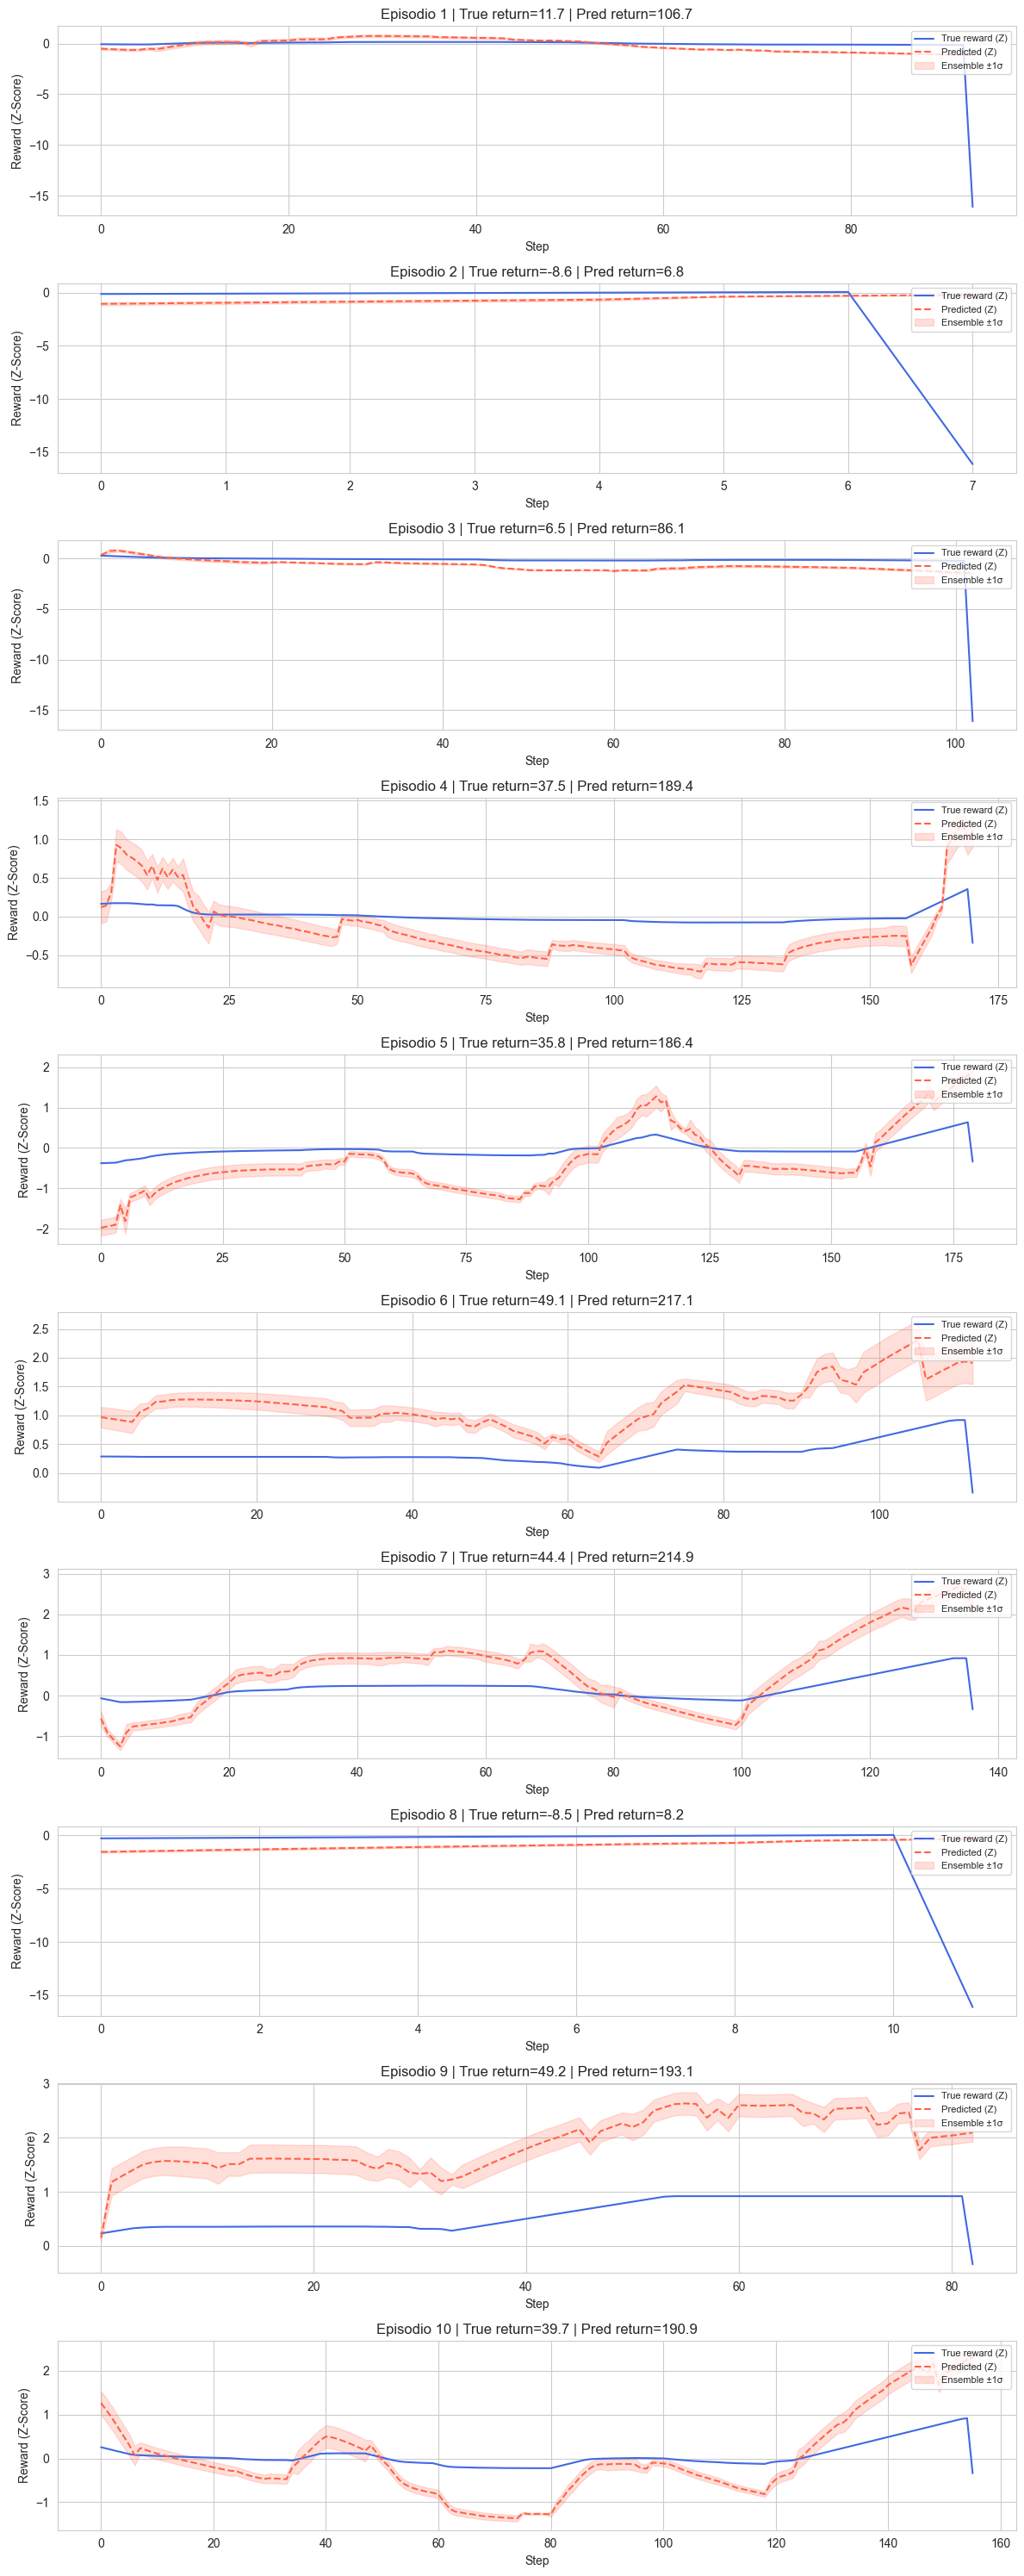

In [20]:
N_SHOW = min(10, len(trajs))

fig, axes = plt.subplots(N_SHOW, 1, figsize=(12, 3 * N_SHOW), sharex=False)
if N_SHOW == 1: axes = [axes]
sns.set_style("whitegrid")

for i, (traj, ax) in enumerate(zip(trajs[:N_SHOW], axes)):
    t = np.arange(len(traj["true_rewards"]))

    # Standardizzazione
    true_z = (traj["true_rewards"] - true_mean) / true_std_val
    pred_z = (traj["pred_rewards_mean"] - pred_mean) / pred_std_val
    uncert_z = traj["pred_rewards_std"] / pred_std_val  # Solo scalato

    ax.plot(t, true_z, label="True reward (Z)", color="royalblue", lw=1.5)
    ax.plot(t, pred_z, label="Predicted (Z)", color="tomato", lw=1.5, ls="--")
    ax.fill_between(t, pred_z - uncert_z, pred_z + uncert_z, alpha=0.2, color="tomato", label="Ensemble ±1σ")

    tr_orig = traj["true_rewards"].sum()
    pr_orig = traj["pred_rewards_mean"].sum()

    ax.set_title(f"Episodio {i+1} | True return={tr_orig:.1f} | Pred return={pr_orig:.1f}")
    ax.set_xlabel("Step"); ax.set_ylabel("Reward (Z-Score)")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

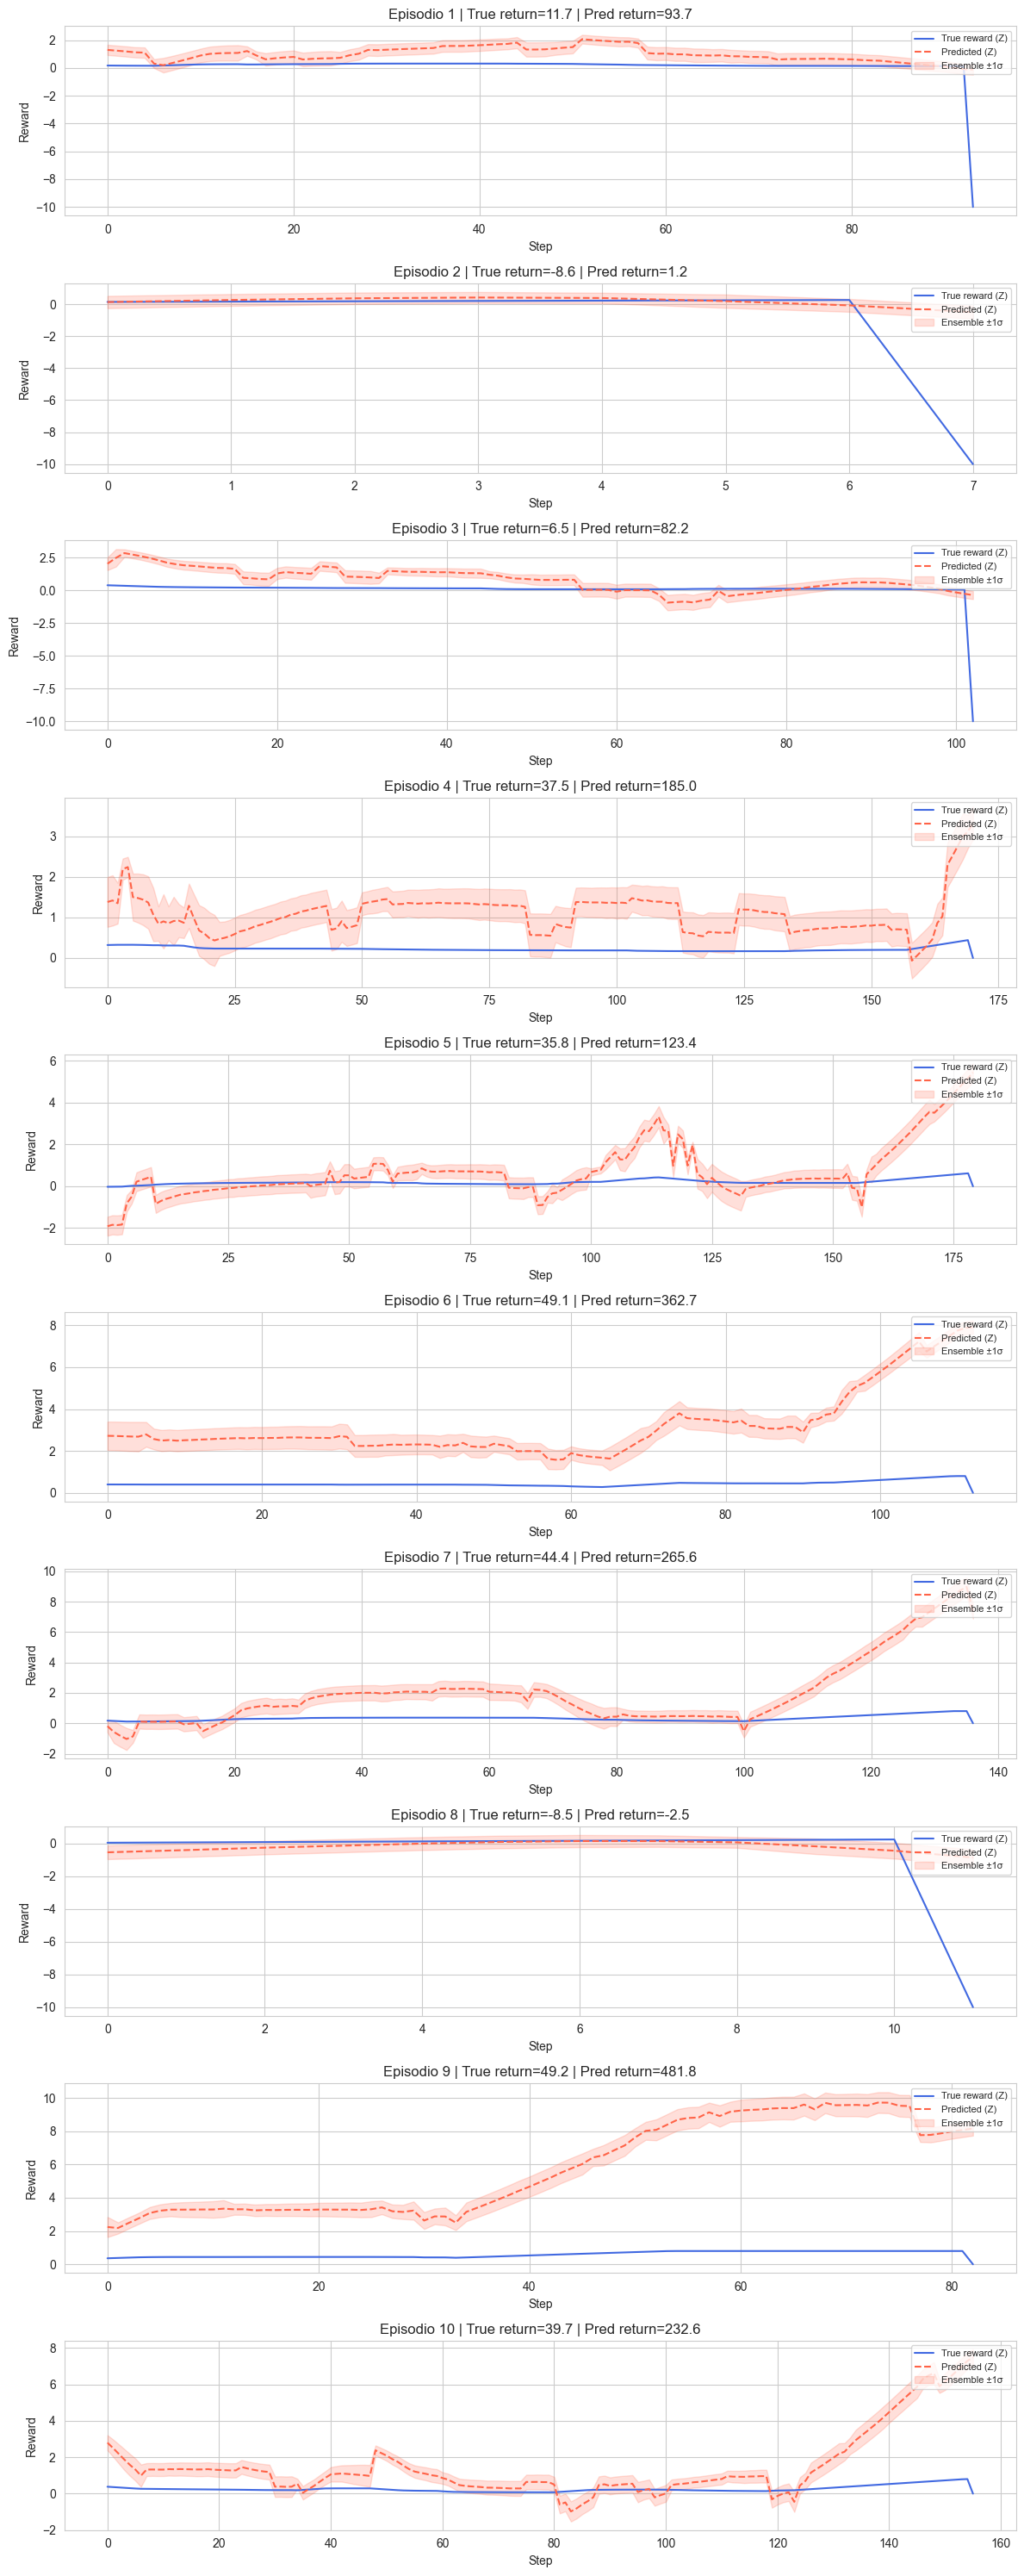

In [6]:
N_SHOW = min(10, len(trajs))

fig, axes = plt.subplots(N_SHOW, 1, figsize=(12, 3 * N_SHOW), sharex=False)
if N_SHOW == 1: axes = [axes]
sns.set_style("whitegrid")

for i, (traj, ax) in enumerate(zip(trajs[:N_SHOW], axes)):
    t = np.arange(len(traj["true_rewards"]))

    # Standardizzazione
    true_z = (traj["true_rewards"])
    pred_z = (traj["pred_rewards_mean"])
    uncert_z = traj["pred_rewards_std"]

    ax.plot(t, true_z, label="True reward (Z)", color="royalblue", lw=1.5)
    ax.plot(t, pred_z, label="Predicted (Z)", color="tomato", lw=1.5, ls="--")
    ax.fill_between(t, pred_z - uncert_z, pred_z + uncert_z, alpha=0.2, color="tomato", label="Ensemble ±1σ")

    tr_orig = traj["true_rewards"].sum()
    pr_orig = traj["pred_rewards_mean"].sum()

    ax.set_title(f"Episodio {i+1} | True return={tr_orig:.1f} | Pred return={pr_orig:.1f}")
    ax.set_xlabel("Step"); ax.set_ylabel("Reward")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

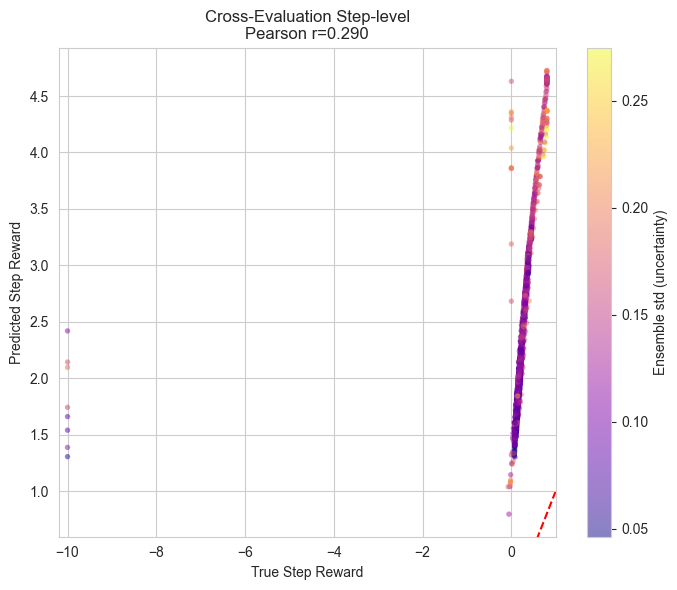

In [6]:
# Campioniamo max 5000 punti per leggibilità
idx = np.random.choice(len(all_true), size=min(5000, len(all_true)), replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(all_true[idx], all_pred[idx], c=all_std[idx],
                cmap="plasma", alpha=0.5, s=15, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Ensemble std (uncertainty)")

# Limiti indipendenti come discusso in precedenza
xlim = (all_true.min() - 0.2, all_true.max() + 0.2)
ylim = (all_pred.min() - 0.2, all_pred.max() + 0.2)
ax.set_xlim(xlim); ax.set_ylim(ylim)

global_min = min(xlim[0], ylim[0])
global_max = max(xlim[1], ylim[1])
ax.plot([global_min, global_max], [global_min, global_max], "r--", lw=1.5, zorder=0)

ax.set_xlabel("True Step Reward")
ax.set_ylabel("Predicted Step Reward")
ax.set_title(f"Cross-Evaluation Step-level\nPearson r={p_step:.3f}")

plt.tight_layout()
plt.show()